In [ ]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow" # Expecitly telling keras to use tensorflow as its backend engine
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from PIL import Image
from sklearn.metrics import confusion_matrix 
import keras
from keras import layers
from keras.models import Sequential
#Task 2 & 3: Dataset exploration and preprocessing 
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32
DATA_DIR = 'images'

print("Loading dataset...")
train_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)
val_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes found:", class_names)
#Caching and prefetching for performance optimization
train_ds = train_ds.cache().prefetch(buffer_size=1)
val_ds = val_ds.cache().prefetch(buffer_size=1)




Loading dataset...
Found 480 files belonging to 4 classes.
Using 96 files for validation.
Found 480 files belonging to 4 classes.
Using 96 files for validation.
Classes found: ['dent', 'normal', 'scratch', 'stain']


In [ ]:
#Task 4: Building the CNN Model
data_augmentation = Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")
model = Sequential([
    keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    data_augmentation,
    layers.Rescaling(1./255),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,196 (16.36 MB)

 Trainable params: 4,288,196 (16.36 MB)

 Non-trainable params: 0 (0.00 B)


Starting Training...
Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 276ms/step - accuracy: 0.3229 - loss: 1.3651 - val_accuracy: 0.3438 - val_loss: 1.3484
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 251ms/step - accuracy: 0.3125 - loss: 1.3519 - val_accuracy: 0.3958 - val_loss: 1.3309
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step - accuracy: 0.4167 - loss: 1.3285 - val_accuracy: 0.2708 - val_loss: 1.3366
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step - accuracy: 0.2812 - loss: 1.3493 - val_accuracy: 0.4479 - val_loss: 1.2989
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 233ms/step - accuracy: 0.4062 - loss: 1.3083 - val_accuracy: 0.4375 - val_loss: 1.2643
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 258ms/step - accuracy: 0.3958 - loss: 1.2659 - val_accuracy: 0.4271 - val_loss: 1.2354
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 247ms/step - accuracy: 0.3542 - loss: 1.2633 - val_accuracy: 0.4688 - val_loss: 1.2075
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 237ms/step - accuracy: 0.5208 - loss: 1.2275 - val_accura

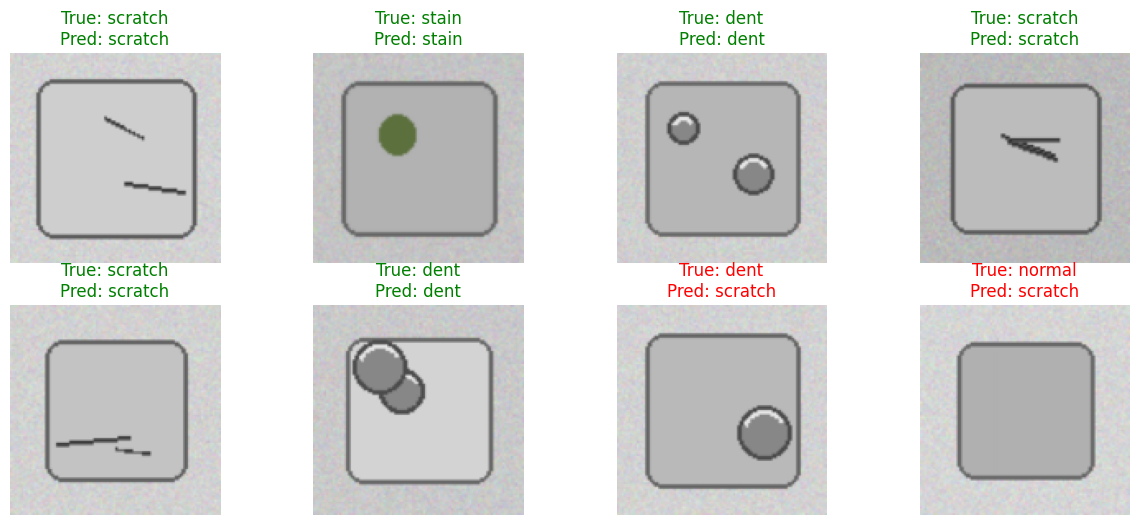

In [16]:
#Task 5: Model training
print("\nStarting Training...")
epochs = 20
history = model.fit(train_ds, validation_data=val_ds, epochs=epochs)

plt.figure(figsize=(15,6))
for images, labels in val_ds.take(1):
    predictions = model.predict(images, verbose=0)
    pred_labels = np.argmax(predictions, axis=1)

    for i in range(8):
        ax = plt.subplot(2,4,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        actual_class = class_names[labels[i]]
        pred_class = class_names[pred_labels[i]]

        color = 'green' if actual_class == pred_class else 'red'
        plt.title(f"True: {actual_class}\nPred: {pred_class}", color=color)
        plt.axis("off")
plt.savefig('sample_predictions/prediction_outputs.png')
plt.show()

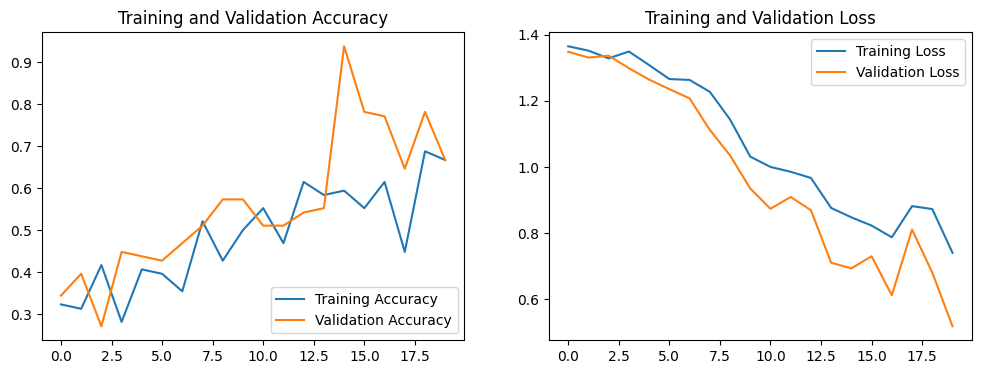


Generating Confusion Matrix...


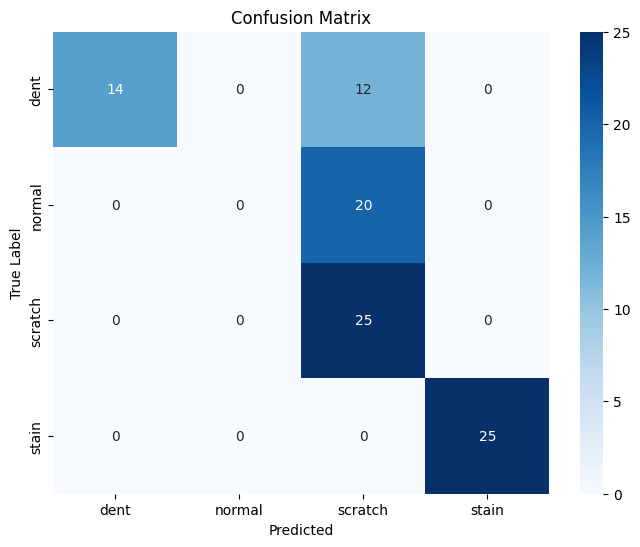

In [17]:
#Task 5: (Contd.) Evaluation and Visualization
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.savefig('results/accuracy_loss_curves.png', bbox_inches='tight')
plt.show()

#Confusion matrix
print("\nGenerating Confusion Matrix...")
y_true = []
y_pred = []
for images, labels in val_ds:
    y_true.extend(np.array(labels))
    predictions = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
             xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.savefig('results/confusion_matrix.png', bbox_inches='tight')
plt.show()